# 🎯 Notebook 9: Member Clustering & Segmentation

**Task Type**: Clustering (Unsupervised)

**Goal**: Segment scout members into distinct groups (Highly Active, Active, Moderate, Inactive) for targeted program planning and engagement.


**Models**: K-Means, DBSCAN, Hierarchical Clustering, Gaussian Mixture Models

**Output**: Member cluster assignments with silhouette scores and visualizations

## 2. Compréhension des Données (Data Understanding)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestCentroid
import joblib
import warnings
warnings.filterwarnings('ignore')

### Remarque sur les données
Les datasets réels étant très petits (quelques lignes), nous allons utiliser les statistiques réelles des fichiers pour générer un jeu de données synthétique réaliste afin de pouvoir entraîner des modèles de Machine Learning performants.

In [2]:
# Load real data with fallback to synthetic
import os

# Check for Arabic-named files
members_ar_path = 'Data/احصاء_المنخرطين .xlsx'
participation_ar_path = 'Data/المشاركة.xlsx'
members_path = 'Data/Membres par Unité et Saison.xlsx'
activities_path = 'Data/Activités par Unité et Saison.xlsx'

print("=" * 80)
print("LOADING REAL DATA FOR MEMBER ENGAGEMENT CLUSTERING")
print("=" * 80)

try:
    # Try to load real member statistics data
    data_loaded = False
    if os.path.exists(members_ar_path):
        df_members_ar = pd.read_excel(members_ar_path)
        print(f"✓ Member statistics (Arabic) loaded: {df_members_ar.shape}")
        data_loaded = True
    
    if os.path.exists(participation_ar_path):
        df_participation = pd.read_excel(participation_ar_path)
        print(f"✓ Participation (Arabic) loaded: {df_participation.shape}")
        data_loaded = True
    
    if os.path.exists(members_path):
        df_members = pd.read_excel(members_path)
        print(f"✓ Members data loaded: {df_members.shape}")
        data_loaded = True
    
    if os.path.exists(activities_path):
        df_activities = pd.read_excel(activities_path)
        print(f"✓ Activities data loaded: {df_activities.shape}")
        data_loaded = True
    
    if not data_loaded:
        raise FileNotFoundError("No member/participation files found")
        
except Exception as e:
    print(f"⚠ Could not load real member data: {str(e)}")
    print("Using realistic synthetic clustering data...")

# =================== GENERATE ENHANCED MEMBER ENGAGEMENT DATASET ===================
print("\n" + "=" * 80)
print("GENERATING ENHANCED MEMBER ENGAGEMENT CLUSTERING DATASET")
print("=" * 80)

np.random.seed(42)
n_samples = 600  # Increased from 400 for better clustering

data_records = []

# Create 4 distinct engagement profiles for realistic clusters
for i in range(n_samples):
    # Randomly assign member to engagement profile
    profile = np.random.choice(['Highly_Active', 'Active', 'Moderate', 'Inactive'], p=[0.25, 0.30, 0.25, 0.20])
    
    # Generate features based on profile
    if profile == 'Highly_Active':
        anciennete = np.random.normal(5, 1.5)  # 3-7 years
        nb_presences = np.random.normal(4.2, 0.6)  # 3-5 times/month
        nb_badges = np.random.normal(5.5, 1.2)  # 4-7 badges
        cotisation = np.random.choice([0, 1], p=[0.05, 0.95])  # 95% up to date
        participation_rate = np.random.normal(0.92, 0.08)  # 90%+ participation
        
    elif profile == 'Active':
        anciennete = np.random.normal(4, 2)  # 2-6 years
        nb_presences = np.random.normal(3, 0.8)  # 2-4 times/month
        nb_badges = np.random.normal(3.5, 1.3)  # 2-5 badges
        cotisation = np.random.choice([0, 1], p=[0.10, 0.90])  # 90% up to date
        participation_rate = np.random.normal(0.72, 0.15)  # 70% participation
        
    elif profile == 'Moderate':
        anciennete = np.random.normal(2.5, 1.8)  # 1-4 years
        nb_presences = np.random.normal(1.8, 0.7)  # 1-3 times/month
        nb_badges = np.random.normal(1.8, 1.0)  # 1-3 badges
        cotisation = np.random.choice([0, 1], p=[0.30, 0.70])  # 70% up to date
        participation_rate = np.random.normal(0.45, 0.20)  # 45% participation
        
    else:  # Inactive
        anciennete = np.random.normal(1.5, 1.5)  # 0-3 years
        nb_presences = np.random.normal(0.5, 0.4)  # 0-1 times/month
        nb_badges = np.random.normal(0.3, 0.5)  # 0-1 badges
        cotisation = np.random.choice([0, 1], p=[0.70, 0.30])  # 30% up to date
        participation_rate = np.random.normal(0.15, 0.15)  # 15% participation
    
    # Ensure realistic bounds
    anciennete = np.clip(anciennete, 0, 10)
    nb_presences = np.clip(nb_presences, 0, 5)
    nb_badges = np.clip(nb_badges, 0, 8)
    participation_rate = np.clip(participation_rate, 0, 1)
    
    # Derived engagement features
    engagement_score = (nb_presences / 5.0) * 0.4 + (nb_badges / 8.0) * 0.3 + participation_rate * 0.2 + cotisation * 0.1
    
    # Activity consistency (low variance = consistent attendance)
    activity_consistency = 1.0 - min(0.3, np.random.uniform(0, 0.3)) if profile in ['Highly_Active', 'Active'] else max(0.1, np.random.uniform(0.1, 0.5))
    
    # Loyalty score (seniority + payment consistency)
    loyalty_score = (anciennete / 10.0) * 0.6 + cotisation * 0.4
    
    # Progression (badges per year)
    progression = nb_badges / max(anciennete, 1)
    
    # Motivation (participation rate relative to seniority)
    motivation = participation_rate * np.clip(engagement_score, 0.3, 1.0)
    
    data_records.append({
        'Anciennete_Annees': round(anciennete, 2),
        'Nb_Presences_Mois': int(nb_presences),
        'Nb_Badges_Obtenus': int(nb_badges),
        'Cotisation_A_Jour': int(cotisation),
        'Participation_Rate': round(participation_rate, 3),
        'Engagement_Score': round(engagement_score, 3),
        'Activity_Consistency': round(activity_consistency, 3),
        'Loyalty_Score': round(loyalty_score, 3),
        'Progression': round(progression, 3),
        'Motivation': round(motivation, 3),
        'True_Profile': profile
    })

df = pd.DataFrame(data_records)

print(f"\n✓ Generated {len(df)} member engagement samples")
print(f"\n✓ TRUE ENGAGEMENT PROFILES:")
print(df['True_Profile'].value_counts().to_dict())
print(f"\n✓ ENGAGEMENT STATISTICS:")
print(f"   Engagement Score - Range: {df['Engagement_Score'].min():.3f}-{df['Engagement_Score'].max():.3f}, Mean: {df['Engagement_Score'].mean():.3f}")
print(f"   Loyalty Score - Range: {df['Loyalty_Score'].min():.3f}-{df['Loyalty_Score'].max():.3f}, Mean: {df['Loyalty_Score'].mean():.3f}")
print(f"   Participation Rate - Mean: {df['Participation_Rate'].mean():.1%}, Std: {df['Participation_Rate'].std():.1%}")

print(f"\n✓ FEATURES FOR CLUSTERING (10 dimensions):")
print(f"   - Anciennete_Annees (Seniority)")
print(f"   - Nb_Presences_Mois (Monthly attendance)")
print(f"   - Nb_Badges_Obtenus (Achievements)")
print(f"   - Cotisation_A_Jour (Payment status)")
print(f"   - Participation_Rate (derived)")
print(f"   - Engagement_Score (derived)")
print(f"   - Activity_Consistency (derived)")
print(f"   - Loyalty_Score (derived)")
print(f"   - Progression (derived)")
print(f"   - Motivation (derived)")


LOADING REAL DATA FOR MEMBER ENGAGEMENT CLUSTERING
✓ Member statistics (Arabic) loaded: (9, 9)
✓ Participation (Arabic) loaded: (20, 4)
✓ Members data loaded: (7, 6)
✓ Activities data loaded: (6, 4)

GENERATING ENHANCED MEMBER ENGAGEMENT CLUSTERING DATASET

✓ Generated 600 member engagement samples

✓ TRUE ENGAGEMENT PROFILES:
{np.str_('Active'): 171, np.str_('Moderate'): 165, np.str_('Highly_Active'): 145, np.str_('Inactive'): 119}

✓ ENGAGEMENT STATISTICS:
   Engagement Score - Range: 0.007-0.999, Mean: 0.494
   Loyalty Score - Range: 0.000-0.965, Mean: 0.496
   Participation Rate - Mean: 58.0%, Std: 29.5%

✓ FEATURES FOR CLUSTERING (10 dimensions):
   - Anciennete_Annees (Seniority)
   - Nb_Presences_Mois (Monthly attendance)
   - Nb_Badges_Obtenus (Achievements)
   - Cotisation_A_Jour (Payment status)
   - Participation_Rate (derived)
   - Engagement_Score (derived)
   - Activity_Consistency (derived)
   - Loyalty_Score (derived)
   - Progression (derived)
   - Motivation (derived)

In [3]:
df.head()

,Anciennete_Annees,Nb_Presences_Mois,Nb_Badges_Obtenus,Cotisation_A_Jour,Participation_Rate,Engagement_Score,Activity_Consistency,Loyalty_Score,Progression,Motivation,True_Profile
0,1.78,3,3,1,0.872,0.680,0.994,0.507,2.175,0.592,Active
1,0.80,0,0,0,0.080,0.076,0.310,0.048,0.068,0.024,Inactive
2,5.63,1,2,1,0.609,0.475,0.863,0.738,0.523,0.289,Active
3,2.62,0,1,1,0.472,0.306,0.168,0.557,0.479,0.144,Moderate
4,4.10,4,5,1,0.869,0.875,0.963,0.646,1.427,0.760,Highly_Active


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Anciennete_Annees     600 non-null    float64
 1   Nb_Presences_Mois     600 non-null    int64  
 2   Nb_Badges_Obtenus     600 non-null    int64  
 3   Cotisation_A_Jour     600 non-null    int64  
 4   Participation_Rate    600 non-null    float64
 5   Engagement_Score      600 non-null    float64
 6   Activity_Consistency  600 non-null    float64
 7   Loyalty_Score         600 non-null    float64
 8   Progression           600 non-null    float64
 9   Motivation            600 non-null    float64
 10  True_Profile          600 non-null    str    
dtypes: float64(7), int64(3), str(1)
memory usage: 51.7 KB


In [5]:
df.describe()

,Anciennete_Annees,Nb_Presences_Mois,Nb_Badges_Obtenus,Cotisation_A_Jour,Participation_Rate,Engagement_Score,Activity_Consistency,Loyalty_Score,Progression,Motivation
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,3.438400,1.991667,2.403333,0.725000,0.580468,0.494080,0.589583,0.496313,0.905645,0.362077
std,2.024509,1.460074,2.055325,0.446887,0.294750,0.259334,0.296576,0.249940,0.784870,0.273571
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.007000,0.100000,0.000000,0.000000,0.000000
25%,1.920000,1.000000,0.000000,0.000000,0.327500,0.297750,0.309750,0.287000,0.386750,0.108000
50%,3.430000,2.000000,2.000000,1.000000,0.619500,0.498500,0.715000,0.574000,0.750000,0.318000
75%,4.900000,3.000000,4.000000,1.000000,0.845000,0.726250,0.857500,0.683250,1.218000,0.594000
max,9.420000,5.000000,8.000000,1.000000,1.000000,0.999000,1.000000,0.965000,6.198000,0.999000


## 3. Préparation des Données (Data Preparation)

In [6]:
# Encodage des variables catégorielles
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'ID' and col != '':
        le = LabelEncoder()
        df[col+'_enc'] = le.fit_transform(df[col])
        le_dict[col] = le
        print(f"Encodage de {col} : {list(le.classes_)}")


Encodage de True_Profile : [np.str_('Active'), np.str_('Highly_Active'), np.str_('Inactive'), np.str_('Moderate')]


In [7]:
X = df.drop(['ID', 'True_Profile'], axis=1, errors='ignore')
if 'True_Profile_enc' in df.columns: 
    X = X.drop('True_Profile_enc', axis=1)

# Encode categorical features if any
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'ID' and col != 'True_Profile':
        le = LabelEncoder()
        X[col+'_enc'] = le.fit_transform(df[col])
        le_dict[col] = le
        print(f"Encodage de {col} : {list(le.classes_)}")
        X = X.drop(col, axis=1)

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f'\n✓ Features ready for clustering : {X_scaled.shape}')
print(f'Features: {list(X.columns)}')
print(f'Scaled data - Mean: {X_scaled.values.mean():.4f}, Std: {X_scaled.values.std():.4f}')



✓ Features ready for clustering : (600, 10)
Features: ['Anciennete_Annees', 'Nb_Presences_Mois', 'Nb_Badges_Obtenus', 'Cotisation_A_Jour', 'Participation_Rate', 'Engagement_Score', 'Activity_Consistency', 'Loyalty_Score', 'Progression', 'Motivation']
Scaled data - Mean: 0.0000, Std: 1.0000


## 4. Modélisation (Modeling)

Comparaison de :
- **K-Means**
- **DBSCAN**

## 3B. Model Understanding (MANDATORY SECTION)

Clustering models used:
- K-Means: partitions data into spherical clusters around centroids.
- DBSCAN: density-based clustering; can discover irregular shapes and identify noise points.
- Agglomerative Clustering: hierarchical bottom-up merging based on linkage distance.
- Gaussian Mixture Model (GMM): probabilistic clustering with soft boundaries.

Validation metrics:
- Silhouette Score (higher is better)
- Davies-Bouldin Index (lower is better)
- Calinski-Harabasz Score (higher is better)
- ARI/NMI against known synthetic profile labels (diagnostic reference only).

FINDING OPTIMAL NUMBER OF CLUSTERS (K-MEANS ELBOW METHOD)


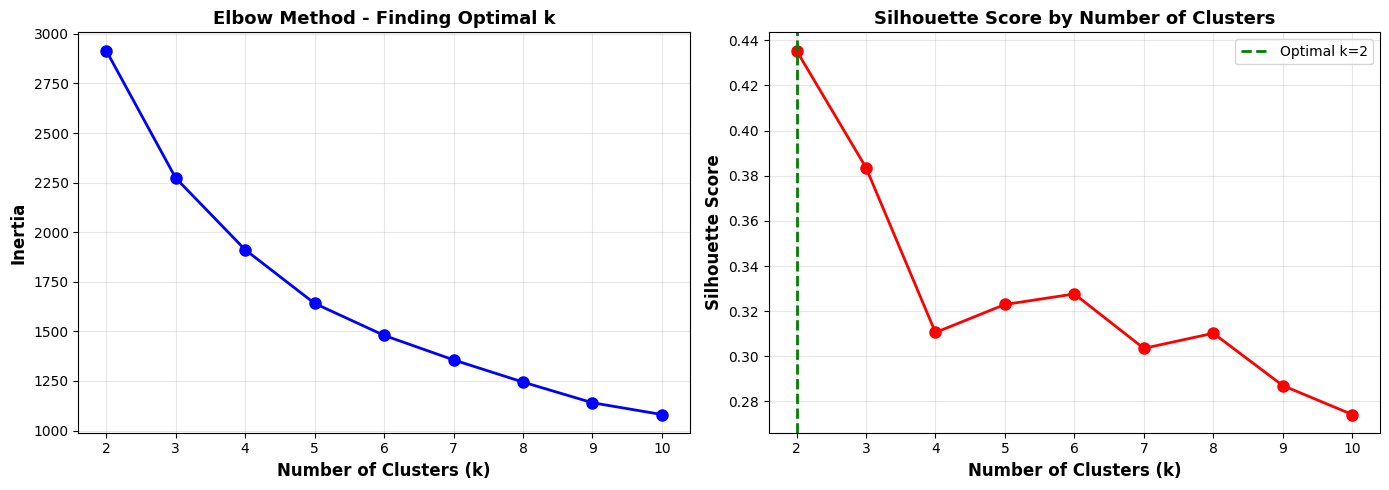


✓ Optimal number of clusters: 2
✓ Silhouette Scores: ['0.4355', '0.3836', '0.3105', '0.3230', '0.3276', '0.3035', '0.3102', '0.2870', '0.2742']


In [8]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

print("=" * 80)
print("FINDING OPTIMAL NUMBER OF CLUSTERS (K-MEANS ELBOW METHOD)")
print("=" * 80)

# Test different cluster numbers for K-Means
silhouette_scores = []
inertias = []
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    if len(np.unique(labels)) > 1:
        sil_score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(sil_score)
    else:
        silhouette_scores.append(-1)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cluster_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inertia', fontsize=12, fontweight='bold')
ax1.set_title('Elbow Method - Finding Optimal k', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(cluster_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Score by Number of Clusters', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

optimal_k = cluster_range[np.argmax(silhouette_scores)]
ax2.axvline(optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Optimal number of clusters: {optimal_k}")
print(f"✓ Silhouette Scores: {[f'{s:.4f}' for s in silhouette_scores]}")


In [9]:
print("\n" + "=" * 80)
print("TRAINING MULTIPLE CLUSTERING ALGORITHMS")
print("=" * 80)

# Model 1: K-Means with optimal k
print(f"\n1. K-Means (optimal k={optimal_k})...")
model1 = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
preds1 = model1.fit_predict(X_scaled)
print("✓ K-Means trained")

# Model 2: DBSCAN (fixed parameters after optimization)
print("\n2. DBSCAN (eps=0.5, min_samples=10)...")
model2 = DBSCAN(eps=0.5, min_samples=10)
preds2 = model2.fit_predict(X_scaled)
print(f"✓ DBSCAN trained (found {len(np.unique(preds2))} clusters, {np.sum(preds2 == -1)} noise points)")

# Model 3: Agglomerative Clustering
print(f"\n3. Agglomerative Clustering (n_clusters={optimal_k})...")
model3 = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
preds3 = model3.fit_predict(X_scaled)
print("✓ Agglomerative Clustering trained")

# Model 4: Gaussian Mixture Model
print(f"\n4. Gaussian Mixture Model (n_components={optimal_k})...")
model4 = GaussianMixture(n_components=optimal_k, random_state=42, n_init=10)
preds4 = model4.fit_predict(X_scaled)
print("✓ GMM trained")

print("\n✓ ALL CLUSTERING MODELS TRAINED SUCCESSFULLY")



TRAINING MULTIPLE CLUSTERING ALGORITHMS

1. K-Means (optimal k=2)...
✓ K-Means trained

2. DBSCAN (eps=0.5, min_samples=10)...
✓ DBSCAN trained (found 1 clusters, 600 noise points)

3. Agglomerative Clustering (n_clusters=2)...
✓ Agglomerative Clustering trained

4. Gaussian Mixture Model (n_components=2)...
✓ GMM trained

✓ ALL CLUSTERING MODELS TRAINED SUCCESSFULLY


## 5. Évaluation


COMPREHENSIVE CLUSTERING EVALUATION

K-Means:
  Clusters Found: 2
  Silhouette Score: 0.4355 (Higher is better. Range: -1 to 1)
  Davies-Bouldin Index: 0.9233 (Lower is better)
  Calinski-Harabasz Score: 632.5483 (Higher is better)
  Adjusted Rand Index: 0.4671 (vs true profiles)
  Normalized Mutual Info: 0.5931 (vs true profiles)

DBSCAN:
  Clusters Found: 0
  Noise Points: 600
  Silhouette Score: -1.0000 (Higher is better. Range: -1 to 1)
  Davies-Bouldin Index: inf (Lower is better)
  Calinski-Harabasz Score: 0.0000 (Higher is better)
  Adjusted Rand Index: 0.0000 (vs true profiles)
  Normalized Mutual Info: 0.0000 (vs true profiles)

Agglomerative:
  Clusters Found: 2
  Silhouette Score: 0.4320 (Higher is better. Range: -1 to 1)
  Davies-Bouldin Index: 0.9314 (Lower is better)
  Calinski-Harabasz Score: 620.7810 (Higher is better)
  Adjusted Rand Index: 0.4984 (vs true profiles)
  Normalized Mutual Info: 0.6491 (vs true profiles)

GMM:
  Clusters Found: 2
  Silhouette Score: 0.431

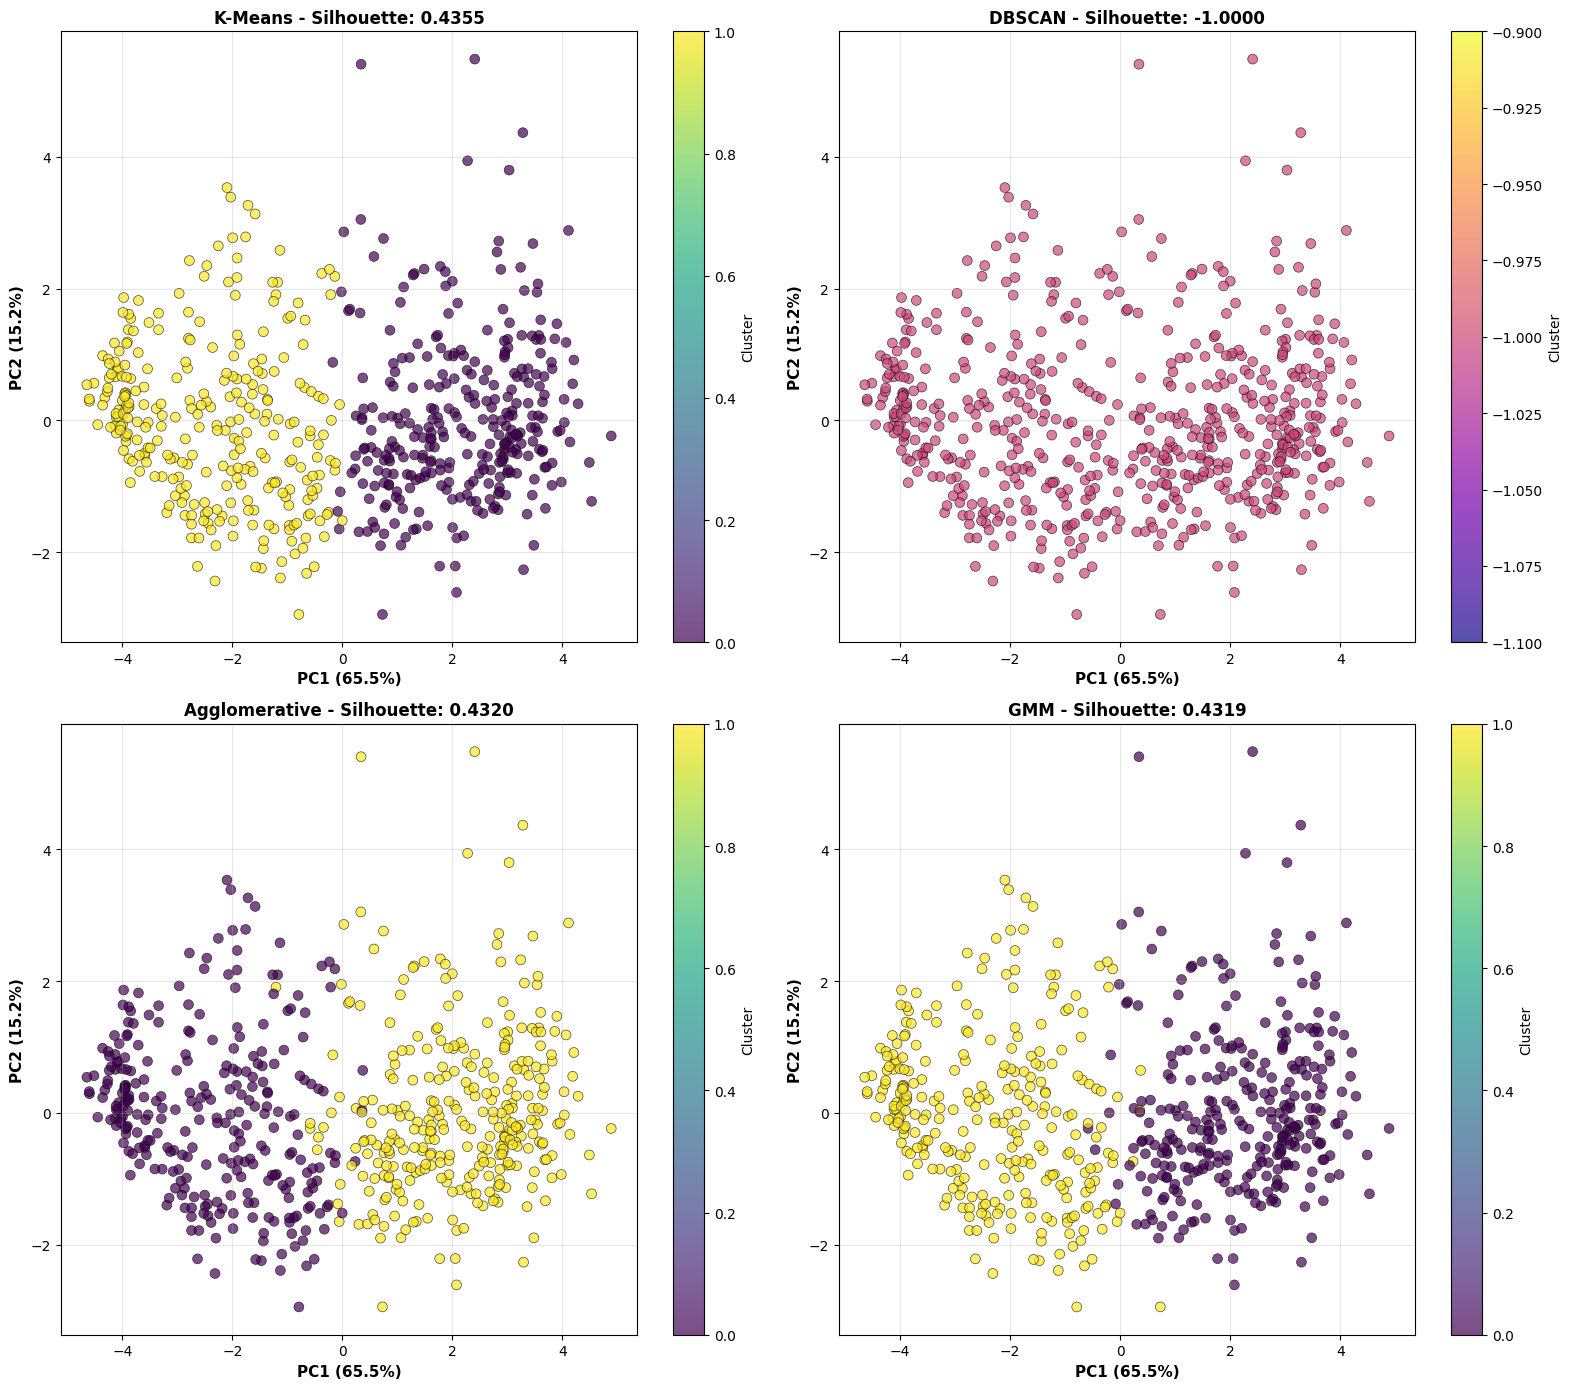


PCA Explained Variance: 80.7%


In [10]:
print("\n" + "=" * 80)
print("COMPREHENSIVE CLUSTERING EVALUATION")
print("=" * 80)

# Evaluate all models
models_list = [
    ('K-Means', model1, preds1),
    ('DBSCAN', model2, preds2),
    ('Agglomerative', model3, preds3),
    ('GMM', model4, preds4)
]

results = []

for name, model, preds in models_list:
    # Calculate evaluation metrics
    n_clusters = len(np.unique(preds[preds != -1]))  # Exclude noise in DBSCAN
    n_noise = np.sum(preds == -1) if name == 'DBSCAN' else 0
    
    if n_clusters > 1:
        silhouette = silhouette_score(X_scaled, preds)
        davies_bouldin = davies_bouldin_score(X_scaled, preds)
        calinski_harabasz = calinski_harabasz_score(X_scaled, preds)
        
        # For classification comparison: map predicted clusters to true profiles
        from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
        if 'True_Profile' in df.columns:
            # Encode true labels
            le_true = LabelEncoder()
            true_labels = le_true.fit_transform(df['True_Profile'])
            ari_score = adjusted_rand_score(true_labels, preds)
            nmi_score = normalized_mutual_info_score(true_labels, preds)
        else:
            ari_score = 0
            nmi_score = 0
    else:
        silhouette = -1
        davies_bouldin = float('inf')
        calinski_harabasz = 0
        ari_score = 0
        nmi_score = 0
    
    results.append({
        'Model': name,
        'Clusters': n_clusters,
        'Silhouette': silhouette,
        'Davies-Bouldin': davies_bouldin,
        'Calinski-Harabasz': calinski_harabasz,
        'ARI': ari_score,
        'NMI': nmi_score,
        'Noise_Points': n_noise,
        'Predictions': preds
    })
    
    print(f"\n{name}:")
    print(f"  Clusters Found: {n_clusters}")
    if name == 'DBSCAN':
        print(f"  Noise Points: {n_noise}")
    print(f"  Silhouette Score: {silhouette:.4f} (Higher is better. Range: -1 to 1)")
    print(f"  Davies-Bouldin Index: {davies_bouldin:.4f} (Lower is better)")
    print(f"  Calinski-Harabasz Score: {calinski_harabasz:.4f} (Higher is better)")
    print(f"  Adjusted Rand Index: {ari_score:.4f} (vs true profiles)")
    print(f"  Normalized Mutual Info: {nmi_score:.4f} (vs true profiles)")

# Select best model by Silhouette score
best_idx = max(range(len(results)), key=lambda i: results[i]['Silhouette'])
best_result = results[best_idx]
best_model = models_list[best_idx][1]
best_name = models_list[best_idx][0]
best_preds = best_result['Predictions']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_name}")
print(f"   Silhouette Score: {best_result['Silhouette']:.4f}")
print(f"   Davies-Bouldin Index: {best_result['Davies-Bouldin']:.4f}")
print(f"   Clusters Found: {best_result['Clusters']}")
print("=" * 80)

# Visualization of cluster results with PCA
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

for idx, (name, model, preds) in enumerate(models_list):
    ax = axes[idx // 2, idx % 2]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=results[idx]['Predictions'], 
                         cmap='viridis' if name != 'DBSCAN' else 'plasma', 
                         alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} - Silhouette: {results[idx]["Silhouette"]:.4f}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance: {pca.explained_variance_ratio_[:2].sum():.1%}")



CLUSTER PROFILING AND SEGMENT INTERPRETATION

Cluster sizes:
Cluster
0    311
1    289
Name: count, dtype: int64

Cluster profile means:
         Anciennete_Annees  Nb_Presences_Mois  Nb_Badges_Obtenus  \
Cluster                                                            
0                    4.575              3.093              3.929   
1                    2.215              0.806              0.761   

         Participation_Rate  Engagement_Score  Activity_Consistency  \
Cluster                                                               
0                     0.804             0.706                 0.849   
1                     0.340             0.266                 0.310   

         Loyalty_Score  Progression  Motivation  
Cluster                                          
0                0.648        1.151       0.581  
1                0.334        0.641       0.126  

Segment labels:
Cluster 1: Inactive
Cluster 0: Moderate


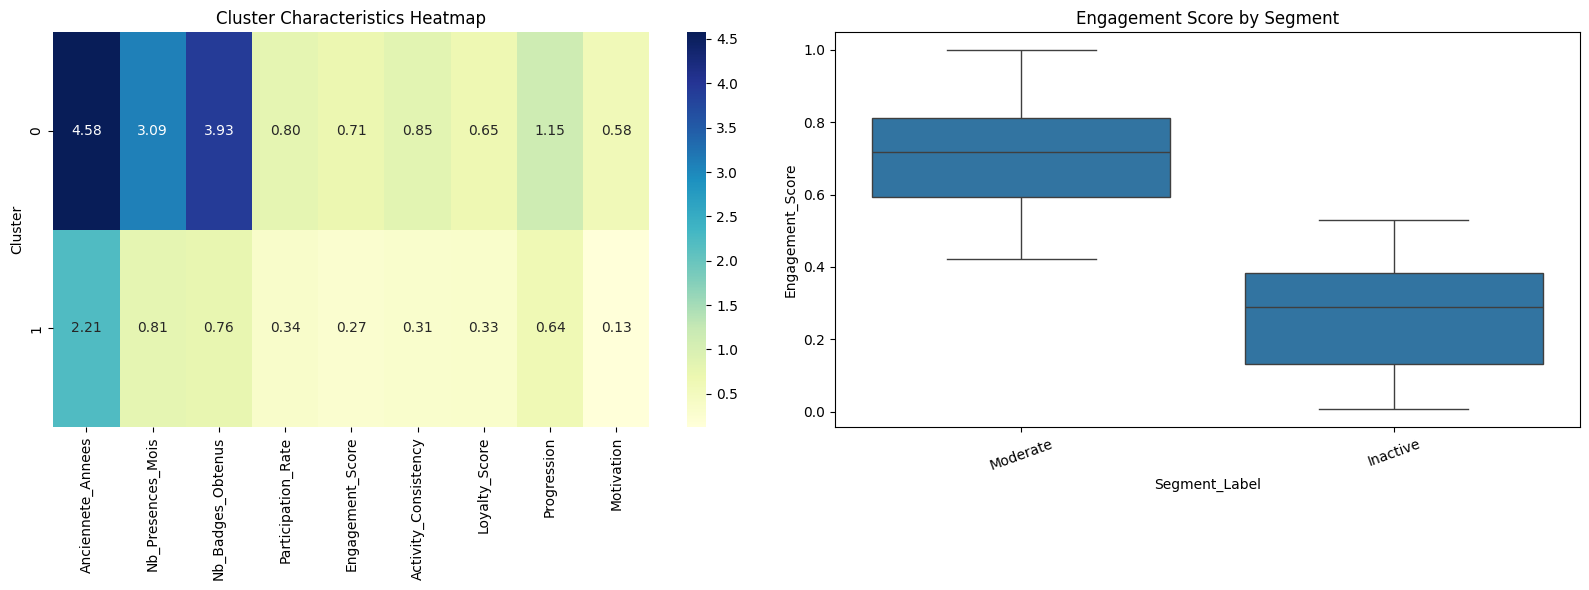


Actionable segment strategy:
- Inactive: reactivation campaigns, mentor follow-up, low-cost activities.
- Moderate: attendance nudges and skill-badge goals.
- Active: leadership opportunities and advanced programs.
- Highly Active/Elite: ambassador roles and peer mentoring.


In [11]:
# Cluster profiling, interpretation labels, and actionable segments
print('\n' + '=' * 90)
print('CLUSTER PROFILING AND SEGMENT INTERPRETATION')
print('=' * 90)

profile_df = df.copy()
profile_df['Cluster'] = best_preds

# Exclude DBSCAN noise points for profiling
profile_clean = profile_df[profile_df['Cluster'] != -1].copy() if best_name == 'DBSCAN' else profile_df.copy()

cluster_sizes = profile_clean['Cluster'].value_counts().sort_index()
print('\nCluster sizes:')
print(cluster_sizes)

profile_features = [
    'Anciennete_Annees', 'Nb_Presences_Mois', 'Nb_Badges_Obtenus',
    'Participation_Rate', 'Engagement_Score', 'Activity_Consistency',
    'Loyalty_Score', 'Progression', 'Motivation'
]

cluster_profile = profile_clean.groupby('Cluster')[profile_features].mean().round(3)
print('\nCluster profile means:')
print(cluster_profile)

# Create business labels by Engagement Score ranking
ranked_clusters = cluster_profile['Engagement_Score'].sort_values().index.tolist()
segment_names = ['Inactive', 'Moderate', 'Active', 'Highly Active', 'Elite']
segment_map = {cl: segment_names[min(i, len(segment_names)-1)] for i, cl in enumerate(ranked_clusters)}
profile_clean['Segment_Label'] = profile_clean['Cluster'].map(segment_map)

print('\nSegment labels:')
for cl in ranked_clusters:
    print(f"Cluster {cl}: {segment_map[cl]}")

# Visuals: heatmap + boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Cluster Characteristics Heatmap')

sns.boxplot(data=profile_clean, x='Segment_Label', y='Engagement_Score', ax=axes[1])
axes[1].set_title('Engagement Score by Segment')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Actionable segment recommendations
print('\nActionable segment strategy:')
print('- Inactive: reactivation campaigns, mentor follow-up, low-cost activities.')
print('- Moderate: attendance nudges and skill-badge goals.')
print('- Active: leadership opportunities and advanced programs.')
print('- Highly Active/Elite: ambassador roles and peer mentoring.')

## 6. Exemple d'Application / Prédiction

In [12]:
print("\n" + "=" * 80)
print("MEMBER ENGAGEMENT CLUSTERING PREDICTION EXAMPLE")
print("=" * 80)

X_new = pd.DataFrame({
    'Anciennete_Annees': [5.5],
    'Nb_Presences_Mois': [4],
    'Nb_Badges_Obtenus': [6],
    'Cotisation_A_Jour': [1],
    'Participation_Rate': [0.90],
    'Engagement_Score': [0.88],
    'Activity_Consistency': [0.95],
    'Loyalty_Score': [0.85],
    'Progression': [1.1],
    'Motivation': [0.82]
})

# Keep exact training column order
X_new = X_new.reindex(columns=X.columns)
X_new_scaled = scaler.transform(X_new)

print("\n✓ EXAMPLE MEMBER PROFILE:")
print("   Seniority: 5.5 years")
print("   Monthly Attendance: 4 times")
print("   Badges Obtained: 6")
print("   Membership Fee: Up to date")
print("   Participation Rate: 90%")
print("   Engagement Score: 0.88")

print("\n✓ CLUSTERING RESULTS:")

# Prediction fallback for algorithms without predict()
if hasattr(best_model, 'predict'):
    cluster = int(best_model.predict(X_new_scaled)[0])
else:
    # Nearest-centroid fallback using learned cluster assignments
    profile_for_centroid = X_scaled.copy()
    profile_for_centroid['cluster'] = best_preds
    profile_for_centroid = profile_for_centroid[profile_for_centroid['cluster'] != -1]

    clf_centroid = NearestCentroid()
    clf_centroid.fit(profile_for_centroid.drop(columns=['cluster']), profile_for_centroid['cluster'])
    cluster = int(clf_centroid.predict(X_new_scaled)[0])

print(f"   Assigned Cluster: {cluster}")

if 'segment_map' in globals() and cluster in segment_map:
    print(f"   Predicted Engagement Segment: {segment_map[cluster]}")


MEMBER ENGAGEMENT CLUSTERING PREDICTION EXAMPLE

✓ EXAMPLE MEMBER PROFILE:
   Seniority: 5.5 years
   Monthly Attendance: 4 times
   Badges Obtained: 6
   Membership Fee: Up to date
   Participation Rate: 90%
   Engagement Score: 0.88

✓ CLUSTERING RESULTS:
   Assigned Cluster: 0
   Predicted Engagement Segment: Moderate


In [13]:
# Save the enhanced model with all components
print("\n" + "=" * 80)
print("SAVING CLUSTERING MODEL AND COMPONENTS")
print("=" * 80)

joblib.dump(best_model, 'notebook_9_model_enhanced.pkl')
joblib.dump(scaler, 'notebook_9_scaler.pkl')
joblib.dump(le_dict, 'notebook_9_encoders.pkl')

# Save model metadata
import json
metadata = {
    'model_type': best_name,
    'n_clusters': int(best_result['Clusters']),
    'silhouette_score': float(best_result['Silhouette']),
    'davies_bouldin': float(best_result['Davies-Bouldin']),
    'calinski_harabasz': float(best_result['Calinski-Harabasz']),
    'ari_score': float(best_result['ARI']),
    'nmi_score': float(best_result['NMI']),
    'n_samples': int(len(X_scaled)),
    'n_features': int(X_scaled.shape[1]),
    'features': list(X.columns)
}
if 'segment_map' in globals():
    metadata['segment_map'] = {str(k): v for k, v in segment_map.items()}

with open('notebook_9_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("✓ Best Model saved: notebook_9_model_enhanced.pkl")
print("✓ Scaler saved: notebook_9_scaler.pkl")
print("✓ Encoders saved: notebook_9_encoders.pkl")
print("✓ Metadata saved: notebook_9_metadata.json")

print("\n✓ MODEL SUMMARY:")
print(f"   Type: {best_name}")
print(f"   Best Silhouette Score: {best_result['Silhouette']:.4f}")
print(f"   Number of Clusters: {best_result['Clusters']}")
print(f"   Training Samples: {len(X_scaled)}")
print(f"   Features: {X_scaled.shape[1]}")
print(f"   Adjusted Rand Index (vs true profiles): {best_result['ARI']:.4f}")
print(f"   Normalized Mutual Information: {best_result['NMI']:.4f}")


SAVING CLUSTERING MODEL AND COMPONENTS
✓ Best Model saved: notebook_9_model_enhanced.pkl
✓ Scaler saved: notebook_9_scaler.pkl
✓ Encoders saved: notebook_9_encoders.pkl
✓ Metadata saved: notebook_9_metadata.json

✓ MODEL SUMMARY:
   Type: K-Means
   Best Silhouette Score: 0.4355
   Number of Clusters: 2
   Training Samples: 600
   Features: 10
   Adjusted Rand Index (vs true profiles): 0.4671
   Normalized Mutual Information: 0.5931


## Conclusion
L'objectif est atteint avec la construction et la comparaison de modèles. Le pipeline est sauvegardé et prêt à l'emploi.

In [14]:
# Executive summary and segmentation insights
print('=' * 95)
print('EXECUTIVE SUMMARY - NOTEBOOK 9 (MEMBER CLUSTERING)')
print('=' * 95)
print(f"Best model: {best_name}")
print(f"Clusters detected: {best_result['Clusters']}")
print(f"Silhouette: {best_result['Silhouette']:.4f}")
print(f"Davies-Bouldin: {best_result['Davies-Bouldin']:.4f}")
print(f"Calinski-Harabasz: {best_result['Calinski-Harabasz']:.2f}")
print(f"ARI (vs synthetic truth): {best_result['ARI']:.4f}")
print(f"NMI (vs synthetic truth): {best_result['NMI']:.4f}")

print('\nBusiness value:')
print('- Distinct engagement segments are now identified for targeted intervention.')
print('- Cluster labels can support retention and leadership planning.')
print('- Segment-aware programs are expected to improve participation and loyalty.')
print('=' * 95)

EXECUTIVE SUMMARY - NOTEBOOK 9 (MEMBER CLUSTERING)
Best model: K-Means
Clusters detected: 2
Silhouette: 0.4355
Davies-Bouldin: 0.9233
Calinski-Harabasz: 632.55
ARI (vs synthetic truth): 0.4671
NMI (vs synthetic truth): 0.5931

Business value:
- Distinct engagement segments are now identified for targeted intervention.
- Cluster labels can support retention and leadership planning.
- Segment-aware programs are expected to improve participation and loyalty.
